In [1]:
import dill
import os
import numpy as np
import pandas as pd
import pickle
from tabulate import tabulate
import config as cfg
import uproot
import matplotlib.pyplot as plt

from plotters.post_bdt_variable_plotter import plot_variable

Welcome to JupyROOT 6.28/10


In [2]:
data={}

for sample in cfg.processList["ella_INVestigations"].keys():
    folder_path = "outputs/ella_INVestigations/root_bdtscores"
    file_list = [os.path.join(folder_path, f"{sample}_combined_cut_0-99965.root")]

    df = uproot.concatenate(
        [f"{f}:{'events'}" for f in file_list],
        library="pd"
    )

    df["decay"] = sample

    print(f"Successfully created DataFrame with {len(df)} rows.")
    print(df.head())

    data[sample] = df


#also read P_signal
sigpath = '/r02/lhcb/ejnw2/FCC_outputs_Jan26/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.sample_allocations["hadronic_background"]+cfg.sample_allocations["combined_signal"]:
    df1 = pd.read_pickle(os.path.join(sigpath,f'{sample}.pkl'))
    df1['P_signal'] = df1['bdt_score_2']
    df1['P_not_heavy'] = 1-df1['bdt_score_1'] 
    df1['P_not_light'] = 1-df1['bdt_score_0'] 

    df2 = df1[(df1['P_not_light']>0.99965)&(df1['P_not_heavy']>0.99965)]
    data[sample] = df2

        

/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-almalinux9-gcc11.3.1-opt/py-uproot/5.0.5-xeyqd3/lib/python3.10/site-packages/uproot/interpretation/library.py:795: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = series[name]
/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-almalinux9-gcc11.3.1-opt/py-uproot/5.0.5-xeyqd3/lib/python3.10/site-packages/uproot/interpretation/library.py:795: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = series[name]
/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-alm

Successfully created DataFrame with 29226 rows.
   EVT_Thrust_deltaE  EVT_Thrust_mag  EVT_Thrust_x  EVT_Thrust_xerr  \
0          45.649601        0.962930     -0.936821        41.316620   
1          36.497517        0.917500      1.247111         8.402984   
2          37.271328        0.727076      0.774256        42.240566   
3          34.133854        0.952959     -1.598792        19.747593   
4          39.061562        0.957495     -1.166714        10.384377   

   EVT_Thrust_y  EVT_Thrust_yerr  EVT_Thrust_z  EVT_Thrust_zerr      EVT_e  \
0     -1.062517        48.065887      0.700696        31.215614  47.452679   
1      0.675466         5.553212     -1.847852        12.545899  47.623371   
2     -0.573254        28.392317     -1.149875        61.046299  45.553188   
3     -0.658406         8.038300     -0.066062         2.490371  46.486355   
4     -0.335281         3.614699      0.945507         8.095692  52.442970   

   EVT_hemisEmax_Emiss  ...  ln_Rec_vtx_normd2PV_ave_hem

/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-almalinux9-gcc11.3.1-opt/py-uproot/5.0.5-xeyqd3/lib/python3.10/site-packages/uproot/interpretation/library.py:795: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = series[name]
/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-almalinux9-gcc11.3.1-opt/py-uproot/5.0.5-xeyqd3/lib/python3.10/site-packages/uproot/interpretation/library.py:795: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = series[name]
/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-alm

Successfully created DataFrame with 220 rows.
   EVT_Thrust_deltaE  EVT_Thrust_mag  EVT_Thrust_x  EVT_Thrust_xerr  \
0          25.943966        0.906478      0.022370         3.285804   
1          35.521019        0.958624     -0.482864         5.274783   
2          30.952051        0.921203     -1.270248        17.477625   
3          35.232029        0.900230      1.334957        29.670490   
4          32.773941        0.967248      0.424138        25.270140   

   EVT_Thrust_y  EVT_Thrust_yerr  EVT_Thrust_z  EVT_Thrust_zerr      EVT_e  \
0      0.602252        39.473831      1.384323        89.508896  38.562229   
1     -0.965003        10.454426     -0.885668         9.768718  48.175194   
2     -0.892616        10.995961      1.655087        20.850449  46.212234   
3      0.823264        18.107174      0.207076         5.898359  51.057613   
4     -0.252578        15.776230     -1.047689        61.630199  44.878967   

   EVT_hemisEmax_Emiss  ...  ln_Rec_vtx_normd2PV_ave_hemis

In [3]:
data

{'p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu':        EVT_Thrust_deltaE  EVT_Thrust_mag  EVT_Thrust_x  EVT_Thrust_xerr  \
 0              45.649601        0.962930     -0.936821        41.316620   
 1              36.497517        0.917500      1.247111         8.402984   
 2              37.271328        0.727076      0.774256        42.240566   
 3              34.133854        0.952959     -1.598792        19.747593   
 4              39.061562        0.957495     -1.166714        10.384377   
 ...                  ...             ...           ...              ...   
 29221          35.013496        0.970299      0.833379         6.380960   
 29222          40.342941        0.964538      0.407477         3.433823   
 29223          40.448997        0.920676      0.901473        37.379833   
 29224          30.933481        0.932522     -1.392457        35.302963   
 29225          36.582401        0.876776     -0.904305        42.677841   
 
        EVT_Thrust_y  EVT_Thrust_yerr  EVT_Thrust_

In [4]:
common_cols = list(set(data["p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu"].columns).intersection(data["p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu"].columns))
data_filtered = {}
for decay in data.keys():
    data_filtered[decay] = data[decay][common_cols].copy()
full_data = pd.concat(data_filtered.values(), ignore_index=True)

In [5]:
full_data["decay"].unique()

array(['p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu',
       'p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu', 'p8_ee_Zbb_ecm91',
       'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91',
       'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],
      dtype=object)

In [6]:
Ksnunu = data["p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu"]

Text(0.5, 0, 'EVT_hemisEmin_e')

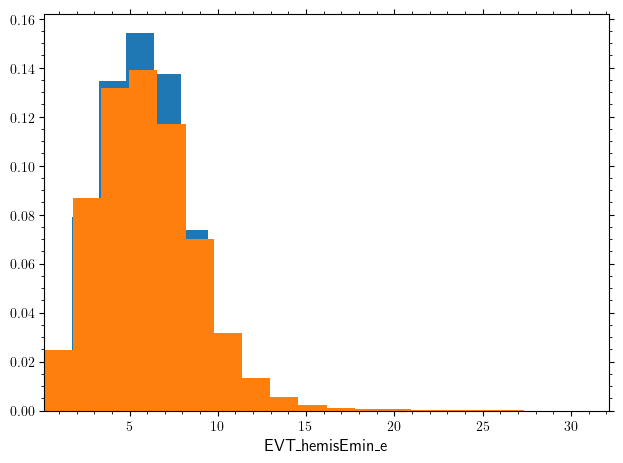

In [7]:
plt.hist(Ksnunu["EVT_hemisEmin_e"], bins=20, density=True)
plt.xlabel("EVT_hemisEmin_e")
plt.hist(data["p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu"]["EVT_hemisEmin_e"], bins=20, density=True)
plt.xlabel("EVT_hemisEmin_e")

In [8]:
len(Ksnunu)/1613716


0.018110993508151374

In [9]:
full_data["decay"].unique()


array(['p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu',
       'p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu', 'p8_ee_Zbb_ecm91',
       'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91',
       'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],
      dtype=object)

In [10]:
cfg.branching_fractions['p8_ee_Zbb_ecm91'][0]

0.1512

p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu
29226
2000000
p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu
220
2000000
p8_ee_Zbb_ecm91
227
438738637
p8_ee_Zcc_ecm91
99
499786495
p8_ee_Zss_ecm91
147
499825860
p8_ee_Zud_ecm91
17
497950940
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
337835
2000000
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
404137
2200000
{'p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu': 0.014613, 'p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu': 0.00011, 'p8_ee_Zbb_ecm91': 5.173923171029042e-07, 'p8_ee_Zcc_ecm91': 1.9808458409825579e-07, 'p8_ee_Zss_ecm91': 2.941024299943184e-07, 'p8_ee_Zud_ecm91': 3.41399094456976e-08, 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': 0.1689175, 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': 0.18369863636363637}
0.014613
p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu
6000000000000.0
2.02e-06
0.014613
177109.56
21851.635825152
BF error currently not correct for exclusive bkg modes
21851.635825152
0.00011
p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu
6000000000000.0
7.93e-06
0.00011
5233.8
645.74205696
BF error currently not correct for exclusive bkg modes
645.74205696


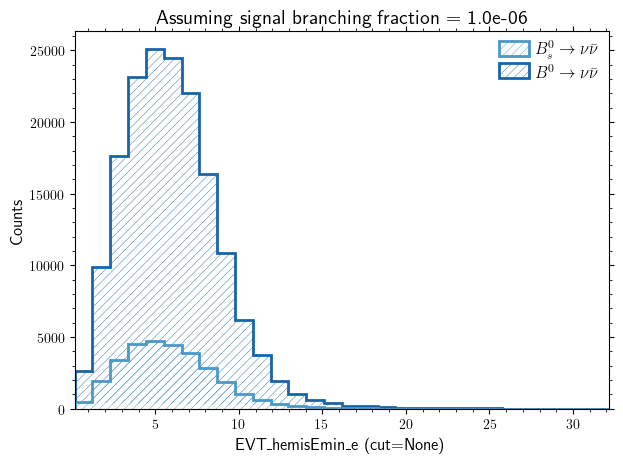

In [11]:
plot_variable(full_data, 'EVT_hemisEmin_e',bins=30, components=["combined_signal"])

p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu
29226
2000000
p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu
220
2000000
p8_ee_Zbb_ecm91
227
438738637
p8_ee_Zcc_ecm91
99
499786495
p8_ee_Zss_ecm91
147
499825860
p8_ee_Zud_ecm91
17
497950940
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
337835
2000000
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
404137
2200000
{'p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu': 0.014613, 'p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu': 0.00011, 'p8_ee_Zbb_ecm91': 5.173923171029042e-07, 'p8_ee_Zcc_ecm91': 1.9808458409825579e-07, 'p8_ee_Zss_ecm91': 2.941024299943184e-07, 'p8_ee_Zud_ecm91': 3.41399094456976e-08, 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': 0.1689175, 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': 0.18369863636363637}
0.014613
p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu
6000000000000.0
2.02e-06
0.014613
177109.56
21851.635825152
BF error currently not correct for exclusive bkg modes
21851.635825152
0.00011
p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu
6000000000000.0
7.93e-06
0.00011
5233.8
645.74205696
BF error currently not correct for exclusive bkg modes
645.74205696


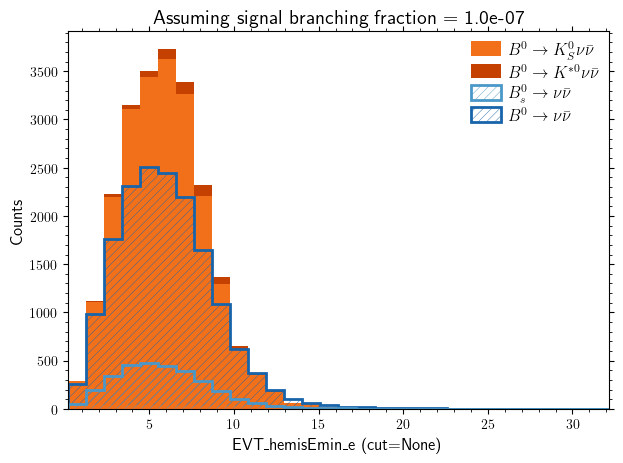

In [17]:
plot_variable(full_data, 'EVT_hemisEmin_e',bins=30, components=["combined_signal","ella_INV"], signal_bf=1e-7)

p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu
29226
2000000
p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu
220
2000000
p8_ee_Zbb_ecm91
227
438738637
p8_ee_Zcc_ecm91
99
499786495
p8_ee_Zss_ecm91
147
499825860
p8_ee_Zud_ecm91
17
497950940
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
337835
2000000
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
404137
2200000
{'p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu': 0.014613, 'p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu': 0.00011, 'p8_ee_Zbb_ecm91': 5.173923171029042e-07, 'p8_ee_Zcc_ecm91': 1.9808458409825579e-07, 'p8_ee_Zss_ecm91': 2.941024299943184e-07, 'p8_ee_Zud_ecm91': 3.41399094456976e-08, 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': 0.1689175, 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': 0.18369863636363637}
0.014613
p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu
6000000000000.0
2.02e-06
0.014613
177109.56
21851.635825152
BF error currently not correct for exclusive bkg modes
21851.635825152
0.00011
p8_ee_Zbb_ecm91_EvtGen_Bd2KstNuNu
6000000000000.0
7.93e-06
0.00011
5233.8
645.74205696
BF error currently not correct for exclusive bkg modes
645.74205696


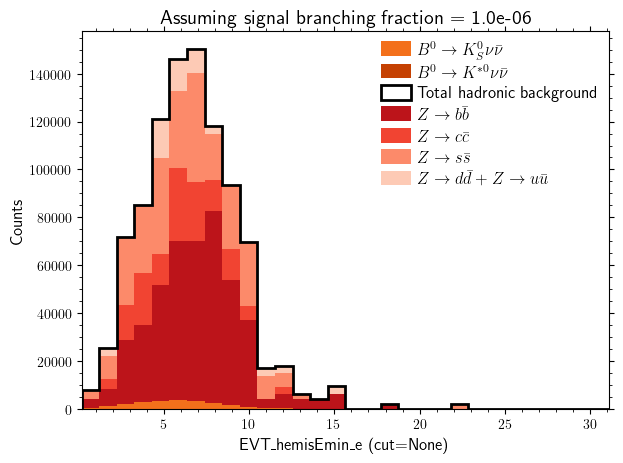

In [13]:
plot_variable(full_data, 'EVT_hemisEmin_e',bins=30, components=["hadronic_background","ella_INV"])